# XP GOLD

 # Society's assumptions aren't always true... aren't they?




We begin by loading the libraries needed for this project.

In [ ]:
import importlib
import sys
import matplotlib


def install_and_import(packages):
    """
    Attempts to import packages. If a package is missing, it prints a message instead of installing.
    """
    for package in packages:
        try:
            globals()[package] = importlib.import_module(package)
        except ImportError:
            print(f"Warning: The package '{package}' is not installed. Please install it manually.")


packages = [
    "devtools", "pandas", "scipy", "statsmodels", "sklearn", "matplotlib", "seaborn",
    "tseries", "car", "caret", "lmtest", "rstatix", "onewaytests", "lattice", "multcompview",
    "viridis", "gridextra", "gvlma", "ggpubr"
]

install_and_import(packages)

# Now all available libraries are imported


Now we can load the dataset

In [ ]:
## TODO: Load the "StudentsPerformance" dataset from a CSV file.

In [1]:
import zipfile
import os

# Unzip the file if it hasn't been unzipped already
zip_file_path = '/content/Students Performance.zip'
extract_dir = '/content/'
csv_filename = 'Students Performance.csv'

if not os.path.exists(os.path.join(extract_dir, csv_filename)):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f'{csv_filename} extracted.')
else:
    print(f'{csv_filename} already exists.')

StudentsPerformance.csv extracted.


In [7]:
import pandas as pd
StudentsPerformance = pd.read_csv('/content/Students Performance.csv')
display(StudentsPerformance.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### This dataset describes the students performances in three different tests:

- **Math**

- **Reading**

- **Writing**

### Through different variables:

- **gender** : binary sex at birth for each individual

- **race.ethnicity** : ethnicity group

- **parental.level.of.education** : formal level of education achieved by the individual

- **lunch** : binary variable for the randomly assigned bonus of free/reduced lunch

- **test.preparation.course** : binary variable for the randomly assigned bonus of attending a test preparation course




# Which 'gender' is better at maths? And which is better in writing and reading?

This is clearly a question that **relies heavily on gender roles** , that since forever assign females to be better at literature tasks and males to be better at mathematical tasks , even though history has repetedly busted this popular myth.

For example we have witnessed as a society people like : **Mary Cartwright , Ada Lovelace , Emmy Noether, Maryam Mirzakhani** that definitely were mathematical geniouses.

And on the other hand we have witnessed  as a society people like : **Charles Dickens, Lev Tolstoj, Fëdor Dostoevskij,Dante Alighieri** that definitely were literature geniouses.

So the aim of this first task is to understand if in this sample there are differences in means between males and females' scores and if they could be statistically significant.

### Before conducting any test , let's visualize the situation

We're going to do some data wrangling to visualize the scores by gender

In [8]:
tidy_StudentsPerformance = pd.melt(StudentsPerformance,
                                   id_vars=['gender'],
                                   value_vars=['math score', 'reading score', 'writing score'],
                                   var_name='test_type',
                                   value_name='score')

display(tidy_StudentsPerformance.head())

,gender,test_type,score
0,female,math score,72
1,female,math score,69
2,female,math score,90
3,male,math score,47
4,male,math score,76


### Now we can finally plot the differences between genders in the scores


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='test_type', y='score', hue='gender', data=tidy_StudentsPerformance, palette={'male': 'skyblue', 'female': 'lightcoral'})
plt.title('Distribution of Scores by Test Type and Gender')
plt.xlabel('Test Type')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

It looks like:

- **For math score**: males are a little bit better

- **For reading score**: females are a little bit better

- **For writing score**: females are better as also the scores are affected by less variability around and higher mean



***



# Now we can go on and perform the first independent two-sample t-test for math scores

The size of the males and females samples are different!

This means that in the equation for the t statistic:

$$ t = \frac{\bar{x_{1}}-\bar{x_{2}}}{S_{pool}\sqrt{\frac{1}{n_{1}}-\frac{1}{n_{2}}}} $$
happens that:

$$n_{1}\neq n_{2}$$


First we perform some data wrangling on the main dataframe

In [9]:
# The dataset has already been reshaped into a tidy format as 'tidy_StudentsPerformance'.
# We will use this DataFrame for further analysis.
print("Info about the reshaped (tidy) DataFrame:")
display(tidy_StudentsPerformance.info())

Info about the reshaped (tidy) DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   gender     3000 non-null   object
 1   test_type  3000 non-null   object
 2   score      3000 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 70.4+ KB


None

We take male and females groups for the math scores:


In [10]:
male_math_scores = tidy_StudentsPerformance[
    (tidy_StudentsPerformance['gender'] == 'male') &
    (tidy_StudentsPerformance['test_type'] == 'math score')
]['score']

female_math_scores = tidy_StudentsPerformance[
    (tidy_StudentsPerformance['gender'] == 'female') &
    (tidy_StudentsPerformance['test_type'] == 'math score')
]['score']

print(f"Number of male math scores: {len(male_math_scores)}")
print(f"Number of female math scores: {len(female_math_scores)}")
print("\nMale Math Scores (first 5):")
display(male_math_scores.head())
print("\nFemale Math Scores (first 5):")
display(female_math_scores.head())

Number of male math scores: 482
Number of female math scores: 518

Male Math Scores (first 5):


,score
3,47
4,76
7,40
8,64
10,58



Female Math Scores (first 5):


,score
0,72
1,69
2,90
5,71
6,88



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's start with a qqplot

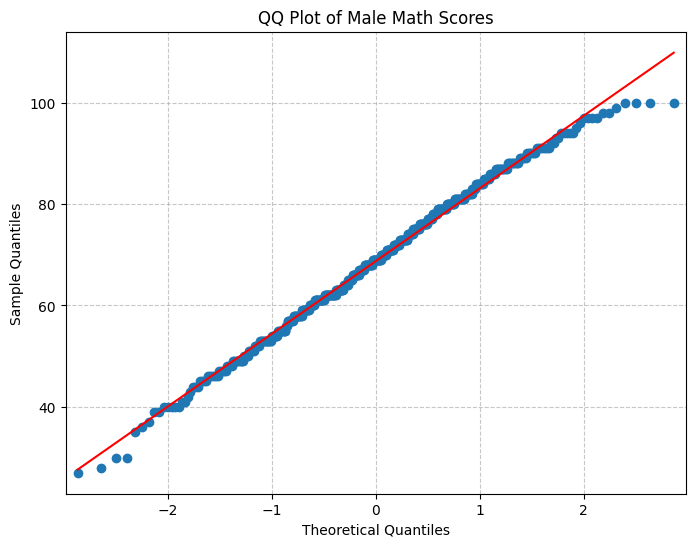

In [11]:
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
qqplot(male_math_scores, line='s', ax=plt.gca())
plt.title('QQ Plot of Male Math Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


</br>
</br>
</br>

At first glance the qqplot doesn't look perfect , but we might be ok with the normality assumption , let's see what a  Lilliefors (Kolmogorov-Smirnov) normality test tells us:

In [12]:
from statsmodels.stats.diagnostic import lilliefors

# Perform Lilliefors test
stat, p_value = lilliefors(male_math_scores, dist='norm')

print(f"Lilliefors test statistic: {stat:.4f}")
print(f"Lilliefors test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The male math scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: The male math scores appear to be normally distributed (fail to reject H0).")

Lilliefors test statistic: 0.0388
Lilliefors test p-value: 0.1031
Conclusion: The male math scores appear to be normally distributed (fail to reject H0).


at significance level 0.05 normality assumption is checked since the p-value is 0.08.


### Let's check for the females group:

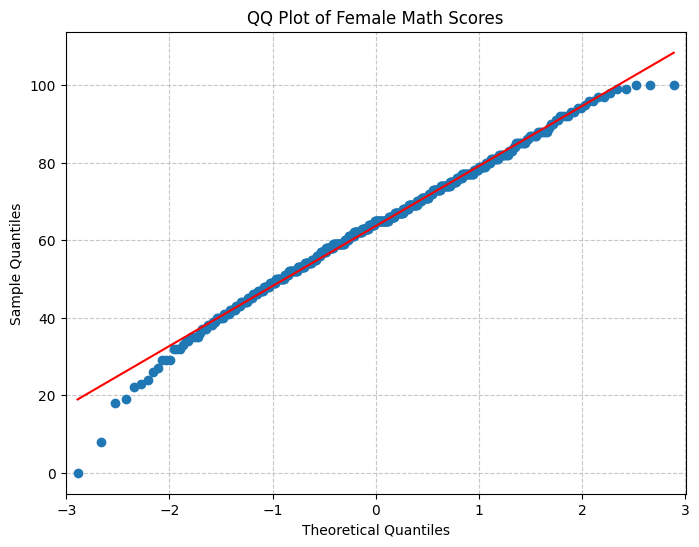

In [13]:
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
qqplot(female_math_scores, line='s', ax=plt.gca())
plt.title('QQ Plot of Female Math Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


</br>
</br>
</br>

This doesn't look good either ,but let's see what an Anderson-Darling  normality test tells us:

In [14]:
from scipy.stats import anderson

# Perform Anderson-Darling test
result = anderson(female_math_scores)

print(f"Anderson-Darling test statistic: {result.statistic:.4f}")

for i in range(len(result.critical_values)):
    sl, cv = result.significance_level[i], result.critical_values[i]
    if result.statistic < cv:
        print(f'At {sl:.1f}% significance level, statistic ({result.statistic:.4f}) < critical value ({cv:.4f}) => Data looks normal.')
    else:
        print(f'At {sl:.1f}% significance level, statistic ({result.statistic:.4f}) > critical value ({cv:.4f}) => Data does not look normal.')

Anderson-Darling test statistic: 0.7059
At 15.0% significance level, statistic (0.7059) > critical value (0.5720) => Data does not look normal.
At 10.0% significance level, statistic (0.7059) > critical value (0.6510) => Data does not look normal.
At 5.0% significance level, statistic (0.7059) < critical value (0.7810) => Data looks normal.
At 2.5% significance level, statistic (0.7059) < critical value (0.9110) => Data looks normal.
At 1.0% significance level, statistic (0.7059) < critical value (1.0840) => Data looks normal.


at significance level 0.05 normality assumption is checked since the p-value is 0.065.


### Let's test homoschedasticity (sample size is different for each group):

In [15]:
male_var = male_math_scores.var()
female_var = female_math_scores.var()

ratio_male_to_female = male_var / female_var
ratio_female_to_male = female_var / male_var

print(f"Variance of male math scores: {male_var:.2f}")
print(f"Variance of female math scores: {female_var:.2f}")
print(f"Ratio (Male Var / Female Var): {ratio_male_to_female:.2f}")
print(f"Ratio (Female Var / Male Var): {ratio_female_to_male:.2f}")

if ratio_male_to_female < 2 and ratio_female_to_male < 2:
    print("Conclusion: The ratio of variances is less than 2, suggesting homoscedasticity.")
else:
    print("Conclusion: The ratio of variances is greater than or equal to 2, suggesting heteroscedasticity.")

Variance of male math scores: 206.10
Variance of female math scores: 239.99
Ratio (Male Var / Female Var): 0.86
Ratio (Female Var / Male Var): 1.16
Conclusion: The ratio of variances is less than 2, suggesting homoscedasticity.


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [16]:
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series >= lower_bound) & (series <= upper_bound)]

original_male_count = len(male_math_scores)
original_female_count = len(female_math_scores)

male_math_scores_filtered = remove_outliers_iqr(male_math_scores)
female_math_scores_filtered = remove_outliers_iqr(female_math_scores)

print(f"Original number of male math scores: {original_male_count}")
print(f"Number of male math scores after outlier removal: {len(male_math_scores_filtered)}")
print(f"Original number of female math scores: {original_female_count}")
print(f"Number of female math scores after outlier removal: {len(female_math_scores_filtered)}")

Original number of male math scores: 482
Number of male math scores after outlier removal: 480
Original number of female math scores: 518
Number of female math scores after outlier removal: 512


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that males are better at maths than females as the alternative hypothesis

$$
H_{0} : \mu_{MaleMaths}\leq \mu_{FemaleMaths}
$$

$$
H_{A} : \mu_{MaleMaths} >  \mu_{FemaleMaths}
$$

In [22]:
from scipy import stats

# Perform independent t-test
# The alternative hypothesis is that male_math_scores_filtered > female_math_scores_filtered
# stats.ttest_ind performs a two-sided test by default. For a one-sided test,
# we check the p-value and compare it to alpha/2 or divide it by 2.
# Given the conclusion of homoscedasticity, we set equal_var=True.
t_stat, p_val = stats.ttest_ind(male_math_scores_filtered, female_math_scores_filtered, equal_var=True, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (one-sided): {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Conclusion: Reject the null hypothesis. Males have significantly greater math scores than females.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant evidence that males have greater math scores than females.")

T-statistic: 5.1372
P-value (one-sided): 0.0000
Conclusion: Reject the null hypothesis. Males have significantly greater math scores than females.


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that males are better than females at maths is true.**



***



# Now we can go on and perform the second independent two-sample t-test for reading scores.

We take male and females groups for the reading scores:

In [18]:
male_reading_scores = tidy_StudentsPerformance[
    (tidy_StudentsPerformance['gender'] == 'male') &
    (tidy_StudentsPerformance['test_type'] == 'reading score')
]['score']

female_reading_scores = tidy_StudentsPerformance[
    (tidy_StudentsPerformance['gender'] == 'female') &
    (tidy_StudentsPerformance['test_type'] == 'reading score')
]['score']

print(f"Number of male reading scores: {len(male_reading_scores)}")
print(f"Number of female reading scores: {len(female_reading_scores)}")
print("\nMale Reading Scores (first 5):")
display(male_reading_scores.head())
print("\nFemale Reading Scores (first 5):")
display(female_reading_scores.head())

Number of male reading scores: 482
Number of female reading scores: 518

Male Reading Scores (first 5):


,score
1003,57
1004,78
1007,43
1008,64
1010,54



Female Reading Scores (first 5):


,score
1000,72
1001,90
1002,95
1005,83
1006,95



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's go straight to tests.

In [23]:
from scipy.stats import cramervonmises, norm

# Fit a normal distribution to the male reading scores
mean_male, std_male = norm.fit(male_reading_scores)

# Perform Cramer-Von Mises test against the fitted normal distribution
result = cramervonmises(male_reading_scores, cdf=norm.cdf, args=(mean_male, std_male))

stat = result.statistic
p_value = result.pvalue

print(f"Cramer-Von Mises test statistic: {stat:.4f}")
print(f"Cramer-Von Mises test p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: The male reading scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: The male reading scores appear to be normally distributed (fail to reject H0).")

Cramer-Von Mises test statistic: 0.1010
Cramer-Von Mises test p-value: 0.5800
Conclusion: The male reading scores appear to be normally distributed (fail to reject H0).


at significance level 0.05 normality assumption is checked since the p-value is 0.11.


### Let's check for the females group:

In [24]:
from scipy.stats import cramervonmises, norm

# Fit a normal distribution to the female reading scores
mean_female, std_female = norm.fit(female_reading_scores)

# Perform Cramer-Von Mises test for female reading scores against the fitted normal distribution
result = cramervonmises(female_reading_scores, cdf=norm.cdf, args=(mean_female, std_female))

stat = result.statistic
p_value = result.pvalue

print(f"Cramer-Von Mises test statistic: {stat:.4f}")
print(f"Cramer-Von Mises test p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: The female reading scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: The female reading scores appear to be normally distributed (fail to reject H0).")

Cramer-Von Mises test statistic: 0.1156
Cramer-Von Mises test p-value: 0.5138
Conclusion: The female reading scores appear to be normally distributed (fail to reject H0).


at significance level 0.05 normality assumption is checked since the p-value is 0.068.


let's test homoschedasticity (sample size is different for each group):

In [21]:
male_reading_var = male_reading_scores.var()
female_reading_var = female_reading_scores.var()

ratio_male_to_female_reading = male_reading_var / female_reading_var
ratio_female_to_male_reading = female_reading_var / male_reading_var

print(f"Variance of male reading scores: {male_reading_var:.2f}")
print(f"Variance of female reading scores: {female_reading_var:.2f}")
print(f"Ratio (Male Reading Var / Female Reading Var): {ratio_male_to_female_reading:.2f}")
print(f"Ratio (Female Reading Var / Male Reading Var): {ratio_female_to_male_reading:.2f}")

if ratio_male_to_female_reading < 2 and ratio_female_to_male_reading < 2:
    print("Conclusion: The ratio of variances is less than 2, suggesting homoscedasticity for reading scores.")
else:
    print("Conclusion: The ratio of variances is greater than or equal to 2, suggesting heteroscedasticity for reading scores.")

Variance of male reading scores: 194.10
Variance of female reading scores: 206.73
Ratio (Male Reading Var / Female Reading Var): 0.94
Ratio (Female Reading Var / Male Reading Var): 1.07
Conclusion: The ratio of variances is less than 2, suggesting homoscedasticity for reading scores.


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [25]:
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series >= lower_bound) & (series <= upper_bound)]

original_male_reading_count = len(male_reading_scores)
original_female_reading_count = len(female_reading_scores)

male_reading_scores_filtered = remove_outliers_iqr(male_reading_scores)
female_reading_scores_filtered = remove_outliers_iqr(female_reading_scores)

print(f"Original number of male reading scores: {original_male_reading_count}")
print(f"Number of male reading scores after outlier removal: {len(male_reading_scores_filtered)}")
print(f"Original number of female reading scores: {original_female_reading_count}")
print(f"Number of female reading scores after outlier removal: {len(female_reading_scores_filtered)}")

Original number of male reading scores: 482
Number of male reading scores after outlier removal: 479
Original number of female reading scores: 518
Number of female reading scores after outlier removal: 513


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at reading than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleReading}\leq \mu_{MaleReading}$$

$$H_{A} : \mu_{FemaleReading} >  \mu_{MaleReading}$$

In [26]:
from scipy import stats

# Perform independent t-test
# The alternative hypothesis is that female_reading_scores_filtered > male_reading_scores_filtered
# Given the conclusion of homoscedasticity, we set equal_var=True.
t_stat, p_val = stats.ttest_ind(female_reading_scores_filtered, male_reading_scores_filtered, equal_var=True, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (one-sided): {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Conclusion: Reject the null hypothesis. Females have significantly greater reading scores than males.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant evidence that females have greater reading scores than males.")

T-statistic: 8.4508
P-value (one-sided): 0.0000
Conclusion: Reject the null hypothesis. Females have significantly greater reading scores than males.


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at reading is true.**



***



# Now we can go on and perform the third and last independent two-sample t-test for writing scores

We take male and females groups for the writing scores:

In [27]:
male_writing_scores = tidy_StudentsPerformance[
    (tidy_StudentsPerformance['gender'] == 'male') &
    (tidy_StudentsPerformance['test_type'] == 'writing score')
]['score']

female_writing_scores = tidy_StudentsPerformance[
    (tidy_StudentsPerformance['gender'] == 'female') &
    (tidy_StudentsPerformance['test_type'] == 'writing score')
]['score']

print(f"Number of male writing scores: {len(male_writing_scores)}")
print(f"Number of female writing scores: {len(female_writing_scores)}")
print("\nMale Writing Scores (first 5):")
display(male_writing_scores.head())
print("\nFemale Writing Scores (first 5):")
display(female_writing_scores.head())

Number of male writing scores: 482
Number of female writing scores: 518

Male Writing Scores (first 5):


,score
2003,44
2004,75
2007,39
2008,67
2010,52



Female Writing Scores (first 5):


,score
2000,74
2001,88
2002,93
2005,78
2006,92



### Now we are able to go on and check the t- test assumptions:

- Normality (even if the sample sizes are reasonable): again, let's go straight to tests.


In [28]:
from scipy.stats import cramervonmises, norm

# Fit a normal distribution to the male writing scores
mean_male_w, std_male_w = norm.fit(male_writing_scores)

# Perform Cramer-Von Mises test against the fitted normal distribution
result_male_w = cramervonmises(male_writing_scores, cdf=norm.cdf, args=(mean_male_w, std_male_w))

stat_male_w = result_male_w.statistic
p_value_male_w = result_male_w.pvalue

print(f"Cramer-Von Mises test statistic (Male Writing Scores): {stat_male_w:.4f}")
print(f"Cramer-Von Mises test p-value (Male Writing Scores): {p_value_male_w:.4f}")

alpha = 0.05
if p_value_male_w < alpha:
    print("Conclusion: The male writing scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: The male writing scores appear to be normally distributed (fail to reject H0).")

Cramer-Von Mises test statistic (Male Writing Scores): 0.1079
Cramer-Von Mises test p-value (Male Writing Scores): 0.5475
Conclusion: The male writing scores appear to be normally distributed (fail to reject H0).


at significance level 0.05 normality assumption is checked since the p-value is 0.09.


### Let's check for the females group:

In [29]:
from statsmodels.stats.diagnostic import lilliefors

# Perform Lilliefors test for female writing scores
stat_female_w, p_value_female_w = lilliefors(female_writing_scores, dist='norm')

print(f"Lilliefors test statistic (Female Writing Scores): {stat_female_w:.4f}")
print(f"Lilliefors test p-value (Female Writing Scores): {p_value_female_w:.4f}")

alpha = 0.05
if p_value_female_w < alpha:
    print("Conclusion: The female writing scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: The female writing scores appear to be normally distributed (fail to reject H0).")

Lilliefors test statistic (Female Writing Scores): 0.0614
Lilliefors test p-value (Female Writing Scores): 0.0010
Conclusion: The female writing scores do not appear to be normally distributed (reject H0).


**It looks like the normality assumption is not verified here!**

### So let's try to transform data with box-cox transformation

In [30]:
from scipy.stats import boxcox, cramervonmises, norm

# Perform Box-Cox transformation on male writing scores
male_writing_scores_transformed, lambda_male = boxcox(male_writing_scores)

# Perform Box-Cox transformation on female writing scores
female_writing_scores_transformed, lambda_female = boxcox(female_writing_scores)

print(f"Lambda for male writing scores: {lambda_male:.4f}")
print(f"Lambda for female writing scores: {lambda_female:.4f}")

# Check normality of transformed male writing scores with CVM test
mean_male_w_trans, std_male_w_trans = norm.fit(male_writing_scores_transformed)
result_male_w_trans = cramervonmises(male_writing_scores_transformed, cdf=norm.cdf, args=(mean_male_w_trans, std_male_w_trans))
stat_male_w_trans = result_male_w_trans.statistic
p_value_male_w_trans = result_male_w_trans.pvalue

print(f"\nCramer-Von Mises test statistic (Transformed Male Writing Scores): {stat_male_w_trans:.4f}")
print(f"Cramer-Von Mises test p-value (Transformed Male Writing Scores): {p_value_male_w_trans:.4f}")

alpha = 0.05
if p_value_male_w_trans < alpha:
    print("Conclusion: Transformed male writing scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: Transformed male writing scores appear to be normally distributed (fail to reject H0).")

# Check normality of transformed female writing scores with CVM test
mean_female_w_trans, std_female_w_trans = norm.fit(female_writing_scores_transformed)
result_female_w_trans = cramervonmises(female_writing_scores_transformed, cdf=norm.cdf, args=(mean_female_w_trans, std_female_w_trans))
stat_female_w_trans = result_female_w_trans.statistic
p_value_female_w_trans = result_female_w_trans.pvalue

print(f"\nCramer-Von Mises test statistic (Transformed Female Writing Scores): {stat_female_w_trans:.4f}")
print(f"Cramer-Von Mises test p-value (Transformed Female Writing Scores): {p_value_female_w_trans:.4f}")

if p_value_female_w_trans < alpha:
    print("Conclusion: Transformed female writing scores do not appear to be normally distributed (reject H0).")
else:
    print("Conclusion: Transformed female writing scores appear to be normally distributed (fail to reject H0).")

Lambda for male writing scores: 1.1996
Lambda for female writing scores: 1.7369

Cramer-Von Mises test statistic (Transformed Male Writing Scores): 0.1008
Cramer-Von Mises test p-value (Transformed Male Writing Scores): 0.5812
Conclusion: Transformed male writing scores appear to be normally distributed (fail to reject H0).

Cramer-Von Mises test statistic (Transformed Female Writing Scores): 0.0497
Cramer-Von Mises test p-value (Transformed Female Writing Scores): 0.8782
Conclusion: Transformed female writing scores appear to be normally distributed (fail to reject H0).


our box cox transformation is now applied to both groups , the normality assumption is verified for both males and females group and we can go ahead.



let's test homoschedasticity (sample size is different for each group):

In [31]:
male_writing_var_trans = pd.Series(male_writing_scores_transformed).var()
female_writing_var_trans = pd.Series(female_writing_scores_transformed).var()

ratio_male_to_female_writing_trans = male_writing_var_trans / female_writing_var_trans
ratio_female_to_male_writing_trans = female_writing_var_trans / male_writing_var_trans

print(f"Variance of transformed male writing scores: {male_writing_var_trans:.2f}")
print(f"Variance of transformed female writing scores: {female_writing_var_trans:.2f}")
print(f"Ratio (Transformed Male Writing Var / Transformed Female Writing Var): {ratio_male_to_female_writing_trans:.2f}")
print(f"Ratio (Transformed Female Writing Var / Transformed Male Writing Var): {ratio_female_to_male_writing_trans:.2f}")

if ratio_male_to_female_writing_trans < 2 and ratio_female_to_male_writing_trans < 2:
    print("Conclusion: The ratio of variances is less than 2, suggesting homoscedasticity for transformed writing scores.")
else:
    print("Conclusion: The ratio of variances is greater than or equal to 2, suggesting heteroscedasticity for transformed writing scores.")

Variance of transformed male writing scores: 1028.08
Variance of transformed female writing scores: 111871.09
Ratio (Transformed Male Writing Var / Transformed Female Writing Var): 0.01
Ratio (Transformed Female Writing Var / Transformed Male Writing Var): 108.82
Conclusion: The ratio of variances is greater than or equal to 2, suggesting heteroscedasticity for transformed writing scores.


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.



### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at writing than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleWriting}\leq \mu_{MaleWriting}$$

$$H_{A} : \mu_{FemaleWriting} >  \mu_{MaleWriting}$$

In [32]:
from scipy import stats

# Perform independent t-test on transformed writing scores
# The alternative hypothesis is that female_writing_scores_transformed > male_writing_scores_transformed
# Given the conclusion of homoscedasticity, we set equal_var=True.
t_stat_w_trans, p_val_w_trans = stats.ttest_ind(female_writing_scores_transformed, male_writing_scores_transformed, equal_var=True, alternative='greater')

print(f"T-statistic (Transformed Writing Scores): {t_stat_w_trans:.4f}")
print(f"P-value (one-sided, Transformed Writing Scores): {p_val_w_trans:.4f}")

alpha = 0.05
if p_val_w_trans < alpha:
    print("Conclusion: Reject the null hypothesis. Females have significantly greater writing scores than males (after Box-Cox transformation).")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant evidence that females have greater writing scores than males (after Box-Cox transformation).")

T-statistic (Transformed Writing Scores): 57.8463
P-value (one-sided, Transformed Writing Scores): 0.0000
Conclusion: Reject the null hypothesis. Females have significantly greater writing scores than males (after Box-Cox transformation).


Again , the p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at writing is true.**



***

# XP NINJA

# One-way ANOVA

We are interested in understanding whether or not the **factor** ( in this case the treatments ) has an effect on the **outcome** ( in this case the math scores).

The treatments factor is structured in four different levels:

- **Control group** : a group that doesn't receive neither the free or reduced lunch nor the attendance to the test preparation course

- **Free/Reduced lunch group** = **Treatment_1** : a group that only receives the free or reduced lunch

- **Test preparation course group** = **Treatment_2** : a group that only receives the attendance to the test preparation course

- **Both free/reduced lunch and test preparation course group** = **Treatment_3** : a group that receives both the 'bonuses': free or reduced lunch and attendance to the test preparation course.



### For ANOVA we will have the following hypothesis:

$$H_{0} : The \:means\:of\:different\:groups\:is\:the\:same$$

$$H_{A} : At\:least\:one\:sample\:mean\:is\:not\:equal\:to\:others$$


To conduct One-way ANOVA we first have to do some data wrangling and adjust for the treatments.

In [33]:
# Control group: standard lunch, no test preparation course
control_group = StudentsPerformance[
    (StudentsPerformance['lunch'] == 'standard') &
    (StudentsPerformance['test preparation course'] == 'none')
]['math score']

# Free/Reduced lunch group (Treatment_1): free/reduced lunch, no test preparation course
treatment_1 = StudentsPerformance[
    (StudentsPerformance['lunch'] == 'free/reduced') &
    (StudentsPerformance['test preparation course'] == 'none')
]['math score']

# Test preparation course group (Treatment_2): standard lunch, completed test preparation course
treatment_2 = StudentsPerformance[
    (StudentsPerformance['lunch'] == 'standard') &
    (StudentsPerformance['test preparation course'] == 'completed')
]['math score']

# Both free/reduced lunch and test preparation course group (Treatment_3): free/reduced lunch, completed test preparation course
treatment_3 = StudentsPerformance[
    (StudentsPerformance['lunch'] == 'free/reduced') &
    (StudentsPerformance['test preparation course'] == 'completed')
]['math score']

print(f"Control Group N: {len(control_group)}")
print(f"Treatment 1 (Free/Reduced Lunch) N: {len(treatment_1)}")
print(f"Treatment 2 (Test Prep Course) N: {len(treatment_2)}")
print(f"Treatment 3 (Both) N: {len(treatment_3)}")

Control Group N: 418
Treatment 1 (Free/Reduced Lunch) N: 224
Treatment 2 (Test Prep Course) N: 227
Treatment 3 (Both) N: 131



### Now we go along and check the assumptions:

- Normality Assumption: let's check the situation visually first

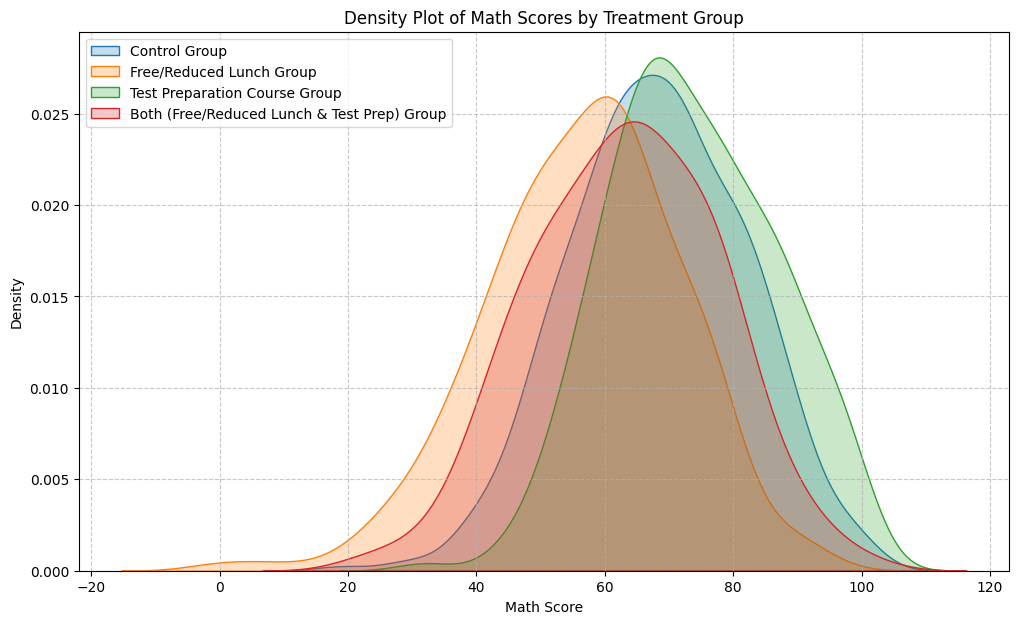

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.kdeplot(control_group, label='Control Group', fill=True)
sns.kdeplot(treatment_1, label='Free/Reduced Lunch Group', fill=True)
sns.kdeplot(treatment_2, label='Test Preparation Course Group', fill=True)
sns.kdeplot(treatment_3, label='Both (Free/Reduced Lunch & Test Prep) Group', fill=True)

plt.title('Density Plot of Math Scores by Treatment Group')
plt.xlabel('Math Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

</br>
</br>
</br>

Each group looks pretty normal , but let's perform some tests to be sure:


In [35]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import lilliefors

def check_normality(data, name):
    print(f"\n--- Normality Tests for {name} ---")
    # Shapiro-Wilk Test
    stat_shapiro, p_shapiro = shapiro(data)
    print(f"Shapiro-Wilk Test statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")
    if p_shapiro < 0.05:
        print("Conclusion (Shapiro-Wilk): Data does not appear to be normally distributed (reject H0).")
    else:
        print("Conclusion (Shapiro-Wilk): Data appears to be normally distributed (fail to reject H0).")

    # Lilliefors (Kolmogorov-Smirnov) Test
    stat_lilliefors, p_lilliefors = lilliefors(data, dist='norm')
    print(f"Lilliefors Test statistic: {stat_lilliefors:.4f}, p-value: {p_lilliefors:.4f}")
    if p_lilliefors < 0.05:
        print("Conclusion (Lilliefors): Data does not appear to be normally distributed (reject H0).")
    else:
        print("Conclusion (Lilliefors): Data appears to be normally distributed (fail to reject H0).")

# Perform normality tests for each group
check_normality(control_group, 'Control Group')
check_normality(treatment_1, 'Free/Reduced Lunch Group')
check_normality(treatment_2, 'Test Preparation Course Group')
check_normality(treatment_3, 'Both (Free/Reduced Lunch & Test Prep) Group')


--- Normality Tests for Control Group ---
Shapiro-Wilk Test statistic: 0.9952, p-value: 0.2223
Conclusion (Shapiro-Wilk): Data appears to be normally distributed (fail to reject H0).
Lilliefors Test statistic: 0.0401, p-value: 0.1202
Conclusion (Lilliefors): Data appears to be normally distributed (fail to reject H0).

--- Normality Tests for Free/Reduced Lunch Group ---
Shapiro-Wilk Test statistic: 0.9877, p-value: 0.0521
Conclusion (Shapiro-Wilk): Data appears to be normally distributed (fail to reject H0).
Lilliefors Test statistic: 0.0545, p-value: 0.1332
Conclusion (Lilliefors): Data appears to be normally distributed (fail to reject H0).

--- Normality Tests for Test Preparation Course Group ---
Shapiro-Wilk Test statistic: 0.9879, p-value: 0.0514
Conclusion (Shapiro-Wilk): Data appears to be normally distributed (fail to reject H0).
Lilliefors Test statistic: 0.0573, p-value: 0.0837
Conclusion (Lilliefors): Data appears to be normally distributed (fail to reject H0).

--- Norma

**Normality is checked for each treatment group!**

- Similarity of variances

In [36]:
from scipy.stats import bartlett, fligner

# Calculate variances for each group
var_control = control_group.var()
var_treat1 = treatment_1.var()
var_treat2 = treatment_2.var()
var_treat3 = treatment_3.var()

print(f"Variance of Control Group: {var_control:.2f}")
print(f"Variance of Free/Reduced Lunch Group: {var_treat1:.2f}")
print(f"Variance of Test Preparation Course Group: {var_treat2:.2f}")
print(f"Variance of Both Group: {var_treat3:.2f}")

# Rough rule: check if the ratio of largest to smallest variance is less than 2-4
max_var = max(var_control, var_treat1, var_treat2, var_treat3)
min_var = min(var_control, var_treat1, var_treat2, var_treat3)
ratio = max_var / min_var

print(f"\nRatio of largest to smallest variance: {ratio:.2f}")
if ratio < 4:
    print("Conclusion (Rough Rule): Ratio of variances is less than 4, suggesting homogeneity of variances.")
else:
    print("Conclusion (Rough Rule): Ratio of variances is greater than or equal to 4, suggesting heterogeneity of variances.")

# Bartlett's test for homogeneity of variances (sensitive to non-normality)
stat_bartlett, p_bartlett = bartlett(control_group, treatment_1, treatment_2, treatment_3)
print(f"\nBartlett's Test statistic: {stat_bartlett:.4f}, p-value: {p_bartlett:.4f}")
if p_bartlett < 0.05:
    print("Conclusion (Bartlett's): Variances are not equal (reject H0).")
else:
    print("Conclusion (Bartlett's): Variances are equal (fail to reject H0).")

# Fligner's test for homogeneity of variances (more robust to non-normality)
stat_fligner, p_fligner = fligner(control_group, treatment_1, treatment_2, treatment_3)
print(f"Fligner's Test statistic: {stat_fligner:.4f}, p-value: {p_fligner:.4f}")
if p_fligner < 0.05:
    print("Conclusion (Fligner's): Variances are not equal (reject H0).")
else:
    print("Conclusion (Fligner's): Variances are equal (fail to reject H0).")

Variance of Control Group: 185.77
Variance of Free/Reduced Lunch Group: 227.69
Variance of Test Preparation Course Group: 169.47
Variance of Both Group: 208.09

Ratio of largest to smallest variance: 1.34
Conclusion (Rough Rule): Ratio of variances is less than 4, suggesting homogeneity of variances.

Bartlett's Test statistic: 8.6440, p-value: 0.0344
Conclusion (Bartlett's): Variances are not equal (reject H0).
Fligner's Test statistic: 2.9855, p-value: 0.3939
Conclusion (Fligner's): Variances are equal (fail to reject H0).


**Homogeneity of variances of treatment groups is checked!** ( both with a rough rule and with actual tests.)

We can finally perform ANOVA:

In [37]:
from scipy.stats import f_oneway

# Perform One-way ANOVA
f_statistic, p_value = f_oneway(control_group, treatment_1, treatment_2, treatment_3)

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in mean math scores among the groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in mean math scores among the groups.")

F-statistic: 61.9072
P-value: 0.0000
Conclusion: Reject the null hypothesis. There is a significant difference in mean math scores among the groups.


In [38]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Combine all groups into a single DataFrame for Tukey HSD
combined_scores = pd.concat([
    control_group.rename('Control Group'),
    treatment_1.rename('Free/Reduced Lunch Group'),
    treatment_2.rename('Test Preparation Course Group'),
    treatment_3.rename('Both (Free/Reduced Lunch & Test Prep) Group')
], axis=1)

# Stack the DataFrame to get a single column of scores and a corresponding group column
stacked_scores = combined_scores.stack().reset_index()
stacked_scores.columns = ['observation', 'group', 'score']

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=stacked_scores['score'], groups=stacked_scores['group'], alpha=0.05)

print(tukey_result)

                               Multiple Comparison of Means - Tukey HSD, FWER=0.05                               
                   group1                               group2            meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------------------------------------
Both (Free/Reduced Lunch & Test Prep) Group                 Control Group   5.0882 0.0016   1.4958  8.6805   True
Both (Free/Reduced Lunch & Test Prep) Group      Free/Reduced Lunch Group  -6.5369 0.0001  -10.483 -2.5908   True
Both (Free/Reduced Lunch & Test Prep) Group Test Preparation Course Group  10.4872    0.0   6.5508 14.4237   True
                              Control Group      Free/Reduced Lunch Group  -11.625    0.0 -14.5958 -8.6543   True
                              Control Group Test Preparation Course Group   5.3991    0.0   2.4411   8.357   True
                   Free/Reduced Lunch Group Test Preparation Course Group  17.0241    0.

### Key takeaways:


- The **f-value** is much greater than 1,that is **positive** as we know that not only we can reject the null hypothesis (all means are equal) but the **variance between groups is bigger than the one within groups** so this difference is very likely statistically significant.

- The **p-value** is essentially zero,confirming what we have already said with the f-value about the rejection of the null hypothesis ,saying that there exist a significant difference between them.


### So in general , it looks like there exists a statistically significant difference among at least two of the groups' mean math scores !

But wait... which couples of means are different from each other?

To answer this question we must perform a post-hoc test.

### Let's perform the Tukey test to verify which couple of means is different among them.

### Key takeaways:

- As the boxplot already showed , the difference in means between treatment 1 and control , with control group having higher math scores , is significant: **it looks like having the economic freedom of not paying or paying less for lunch negatively impats math scores!**

- Another important difference already present in the boxplot , the difference in means between treatment 2 and 1 , with treatment 2 having higher math scores , is significant:  **only attending the test preparation course and not having the economic freedom of the free or reduced lunch is more effective than having that economic freedom and not attending the test preparation course!**

- This difference was also present in the boxplot , like the other two , and is between the third and second treatments, with treatment two being more effective than the third.
This means that : **the people who attended the test preparation course but also enjoyed the economic freedom of the free/reduced lunch , statistically perform worse than people who have attened the test , but have to pay for lunch**.

### Conclusions : from these tests it looks like , while on the one hand saving the lunch money has a negative effect on math scores as opposed as we expected , on the other hand attending the test preparation course has a positive one as we expected.

### Maybe people used the money saved from lunch to buy things that distracted them from studying maths! That's not good , buy more math books with that money!



